<a href="https://colab.research.google.com/github/eniompw/microgpt-tinystories/blob/main/microgpt-colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MicroGPT — PyTorch (Colab T4 GPU)

The most atomic way to train and run inference for a GPT in pure PyTorch.
Based on [@karpathy](https://github.com/karpathy)'s microgpt.

> **Runtime:** Go to **Runtime → Change runtime type → T4 GPU** before running.

## 1. GPU Setup and Library Imports

In [1]:
import os
import random
import json
import torch
import torch.nn.functional as F

# Reproducibility
random.seed(42)
torch.manual_seed(42)

# Device setup — will use T4 GPU on Colab
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB


## 2. Dataset Download and Preparation

In [2]:
import urllib.request

if not os.path.exists('input.txt'):
    print("Downloading TinyStories dataset from HuggingFace...")
    stories = []
    base_url = 'https://datasets-server.huggingface.co/rows?dataset=karpathy/tinystories-gpt4-clean&config=default&split=train'
    for offset in range(20000, 21000, 100):  # rows 20000+ are the train split
        url = f'{base_url}&offset={offset}&limit=100'
        with urllib.request.urlopen(url) as response:
            data = json.loads(response.read())
        for item in data['rows']:
            stories.append(item['row']['text'])
        print(f"  fetched {len(stories)} stories...", end='\r')
    print()
    with open('input.txt', 'w') as f:
        for story in stories:
            f.write(json.dumps(story) + '\n')
    print("Saved to input.txt")
else:
    print("input.txt already exists, skipping download.")

docs = [json.loads(line) for line in open('input.txt') if line.strip()]
random.shuffle(docs)
print(f"num docs: {len(docs)}")
print(f"sample doc: {docs[0][:120]}...")

  fetched 1000 stories...
Saved to input.txt
num docs: 1000
sample doc: Once upon a time, in a small house, there lived a brave little girl named Lucy. She loved to help her mom cook in the ki...


## 3. Tokenizer Setup

In [3]:
# Character-level vocabulary — all 74 chars present in the dataset
uchars = sorted('\n !"$\',-.' + '0123456789:;?' + 'ABCDEFGHIJKLMNOPQRSTUVWXYZ' + 'abcdefghijklmnopqrstuvwxyz')
BOS = len(uchars)          # special Beginning-of-Sequence token id
vocab_size = len(uchars) + 1
print(f"vocab size: {vocab_size}")
print(f"BOS token id: {BOS}")

# Encode / decode helpers
encode = lambda s: [uchars.index(ch) for ch in s]
decode = lambda ids: ''.join(uchars[i] for i in ids)

# Sanity check
sample_text = "Once upon a time"
encoded = encode(sample_text)
decoded = decode(encoded)
print(f"encode('{sample_text}') → {encoded}")
print(f"decode(...)           → '{decoded}'")

vocab size: 75
BOS token id: 74
encode('Once upon a time') → [36, 61, 50, 52, 1, 68, 63, 62, 61, 1, 48, 1, 67, 56, 60, 52]
decode(...)           → 'Once upon a time'


## 4. Model Hyperparameters and Parameter Initialization

In [4]:
import math

# ── Hyperparameters (from train.py / model.py) ───────────────────────────────
n_layer    = 5       # transformer depth  (was 2)
n_embd     = 128     # embedding dim      (was 16)
block_size = 256     # context window     (was 16)
n_head     = 8       # attention heads    (was 4)
head_dim   = n_embd // n_head
batch_size = 32
grad_accum_steps = 4

# Pad vocab to multiple of 128 for GPU efficiency
padded_vocab = math.ceil(vocab_size / 128) * 128

# MLP hidden dim (4x, rounded to multiple of 32)
multiple_of = 32
hidden_dim = multiple_of * ((4 * n_embd + multiple_of - 1) // multiple_of)

# ── Weight init ──────────────────────────────────────────────────────────────
matrix = lambda nout, nin: torch.randn(nout, nin, device=device) * 0.02
zeros  = lambda nout, nin: torch.zeros(nout, nin, device=device)

state_dict = {
    'wte': matrix(padded_vocab, n_embd),   # token embeddings (weight-tied to lm_head)
}
for i in range(n_layer):
    state_dict[f'layer{i}.attn_wq'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wk'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wv'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wo'] = zeros(n_embd, n_embd)     # zero-init for stability
    state_dict[f'layer{i}.mlp_fc1'] = matrix(hidden_dim, n_embd)
    state_dict[f'layer{i}.mlp_fc2'] = zeros(n_embd, hidden_dim)  # zero-init for stability

params = list(state_dict.values())
for p in params:
    p.requires_grad_(True)

total_params = sum(p.numel() for p in params)
print(f"num params: {total_params:,}")
print(f"vocab (original/padded): {vocab_size}/{padded_vocab}")
print(f"tokens per iter: {batch_size * block_size * grad_accum_steps:,}")


num params: 999,424
vocab (original/padded): 75/128
tokens per iter: 32,768


## 5. Model Architecture Definition

Llama-style transformer: RMSNorm, RoPE, relu² FFN, weight tying, flash attention.

In [5]:
def rmsnorm(x):
    """RMSNorm along last dim — works for any shape."""
    return x * (x.pow(2).mean(-1, keepdim=True) + 1e-5).rsqrt()

# ── RoPE (Rotary Position Embeddings) ────────────────────────────────────────
freqs = 1.0 / (10000.0 ** (torch.arange(0, head_dim, 2, device=device).float() / head_dim))
freqs = torch.outer(torch.arange(block_size, device=device).float(), freqs)
rope_cos, rope_sin = freqs.cos(), freqs.sin()   # (block_size, head_dim//2)

def apply_rope(x, cos, sin):
    """x: (B,T,H,D) or (H,D). cos/sin: (T,D//2) or (D//2,)"""
    d = x.dtype
    x = x.float().unflatten(-1, (-1, 2))
    x_r, x_i = x[..., 0], x[..., 1]
    if x.dim() == 5:  # batched
        cos = cos.view(1, -1, 1, cos.shape[-1])
        sin = sin.view(1, -1, 1, sin.shape[-1])
    return torch.stack([x_r*cos - x_i*sin, x_r*sin + x_i*cos], -1).flatten(-2).to(d)

# ── Batched forward (for training) ───────────────────────────────────────────
def gpt_train(tokens):
    """tokens: (B, T) long -> logits: (B, T, padded_vocab)"""
    bsz, seqlen = tokens.shape
    x = rmsnorm(F.embedding(tokens, state_dict['wte']))
    cos, sin = rope_cos[:seqlen], rope_sin[:seqlen]
    for li in range(n_layer):
        r = x
        x = rmsnorm(x)
        q = F.linear(x, state_dict[f'layer{li}.attn_wq']).view(bsz, seqlen, n_head, head_dim)
        k = F.linear(x, state_dict[f'layer{li}.attn_wk']).view(bsz, seqlen, n_head, head_dim)
        v = F.linear(x, state_dict[f'layer{li}.attn_wv']).view(bsz, seqlen, n_head, head_dim)
        q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)
        x = F.scaled_dot_product_attention(
            q.transpose(1,2), k.transpose(1,2), v.transpose(1,2), is_causal=True
        ).transpose(1,2).contiguous().view(bsz, seqlen, -1)
        x = F.linear(x, state_dict[f'layer{li}.attn_wo']) + r
        r = x
        x = rmsnorm(x)
        x = F.relu(F.linear(x, state_dict[f'layer{li}.mlp_fc1'])).square()   # relu²
        x = F.linear(x, state_dict[f'layer{li}.mlp_fc2']) + r
    return F.linear(rmsnorm(x), state_dict['wte'])   # weight-tied lm_head

# ── Single-token forward (for inference with KV cache) ───────────────────────
def gpt(token_id, pos_id, keys, values):
    x = rmsnorm(state_dict['wte'][token_id])
    cos, sin = rope_cos[pos_id], rope_sin[pos_id]
    for li in range(n_layer):
        r = x
        x = rmsnorm(x)
        q = F.linear(x, state_dict[f'layer{li}.attn_wq']).view(n_head, head_dim)
        k = F.linear(x, state_dict[f'layer{li}.attn_wk']).view(n_head, head_dim)
        v = F.linear(x, state_dict[f'layer{li}.attn_wv']).view(n_head, head_dim)
        q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)
        keys[li].append(k); values[li].append(v)
        x_attn = []
        for h in range(n_head):
            k_h = torch.stack([ki[h] for ki in keys[li]])
            v_h = torch.stack([vi[h] for vi in values[li]])
            x_attn.append(F.softmax(k_h @ q[h] / head_dim**0.5, dim=0) @ v_h)
        x = F.linear(torch.cat(x_attn), state_dict[f'layer{li}.attn_wo']) + r
        r = x
        x = rmsnorm(x)
        x = F.relu(F.linear(x, state_dict[f'layer{li}.mlp_fc1'])).square()
        x = F.linear(x, state_dict[f'layer{li}.mlp_fc2']) + r
    return F.linear(rmsnorm(x), state_dict['wte'])

print("Model functions defined.")


Model functions defined.


## 6. Training Loop

Total tokens: 819,826
step    0/1000 | loss 4.9520 | lr 5.00e-04 | 0.6s
step  100/1000 | loss 2.4231 | lr 5.00e-04 | 12.9s
step  200/1000 | loss 1.9347 | lr 5.00e-04 | 24.8s
step  300/1000 | loss 1.5930 | lr 5.00e-04 | 36.8s
step  400/1000 | loss 1.4635 | lr 5.00e-04 | 48.7s
step  500/1000 | loss 1.3161 | lr 5.00e-04 | 60.8s
step  600/1000 | loss 1.2717 | lr 5.00e-04 | 72.9s
step  700/1000 | loss 1.1343 | lr 5.00e-04 | 85.1s
step  800/1000 | loss 1.1395 | lr 5.00e-04 | 97.5s
step  900/1000 | loss 1.0697 | lr 5.00e-04 | 109.9s
step 1000/1000 | loss 1.0508 | lr 5.00e-05 | 122.4s

Done in 122.4s


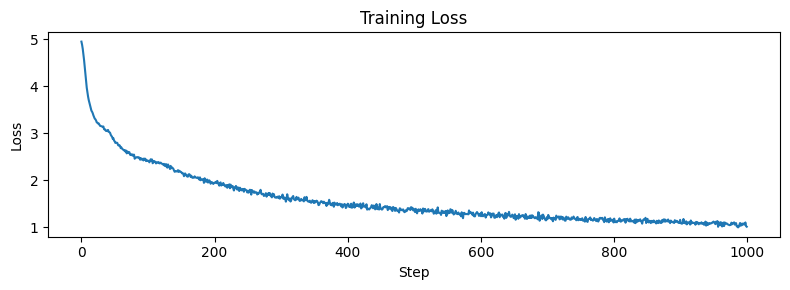

In [6]:
import time
import matplotlib.pyplot as plt

# ── Prepare token stream ─────────────────────────────────────────────────────
all_tokens = []
for doc in docs:
    all_tokens.extend([BOS] + encode(doc))
all_tokens.append(BOS)
all_tokens = torch.tensor(all_tokens, dtype=torch.long, device=device)
print(f"Total tokens: {len(all_tokens):,}")

# ── Optimizer: AdamW with param groups (from train.py) ───────────────────────
num_steps     = 1000
base_lr       = 5e-4
min_lr        = base_lr / 10
cooldown_frac = 0.1
stable_steps  = int(num_steps * (1 - cooldown_frac))

embed_params  = [state_dict['wte']]
matrix_params = [p for n, p in state_dict.items() if n != 'wte']
optimizer = torch.optim.AdamW([
    {'params': embed_params,  'lr': base_lr, 'weight_decay': 0.0},
    {'params': matrix_params, 'lr': base_lr, 'weight_decay': 0.1},
], betas=(0.9, 0.95), eps=1e-10)
for g in optimizer.param_groups:
    g['initial_lr'] = g['lr']

# LR schedule: stable then cosine cooldown (from train.py)
def lr_mult(step):
    if step < stable_steps:
        return 1.0
    if step >= num_steps:
        return min_lr / base_lr
    r = (step - stable_steps) / (num_steps - stable_steps)
    return (min_lr/base_lr) + 0.5*(1+math.cos(math.pi*r))*(1-min_lr/base_lr)

# Mixed precision (float16 on T4)
scaler = torch.amp.GradScaler('cuda')

# ── Training loop ────────────────────────────────────────────────────────────
loss_history = []
t0 = time.time()

for step in range(num_steps + 1):
    for g in optimizer.param_groups:
        g['lr'] = g['initial_lr'] * lr_mult(step)

    if step % 100 == 0:
        with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
            ix = torch.randint(0, len(all_tokens) - block_size - 1, (batch_size,))
            xb = torch.stack([all_tokens[i:i+block_size] for i in ix])
            yb = torch.stack([all_tokens[i+1:i+block_size+1] for i in ix])
            el = F.cross_entropy(gpt_train(xb).view(-1, padded_vocab), yb.view(-1)).item()
        print(f"step {step:4d}/{num_steps} | loss {el:.4f} | lr {optimizer.param_groups[0]['lr']:.2e} | {time.time()-t0:.1f}s")

    if step >= num_steps:
        break

    optimizer.zero_grad()
    for _ in range(grad_accum_steps):
        ix = torch.randint(0, len(all_tokens) - block_size - 1, (batch_size,))
        xb = torch.stack([all_tokens[i:i+block_size] for i in ix])
        yb = torch.stack([all_tokens[i+1:i+block_size+1] for i in ix])
        with torch.amp.autocast('cuda', dtype=torch.float16):
            loss = F.cross_entropy(gpt_train(xb).view(-1, padded_vocab), yb.view(-1)) / grad_accum_steps
        scaler.scale(loss).backward()

    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(params, 1.0)   # gradient clipping
    scaler.step(optimizer)
    scaler.update()
    loss_history.append(loss.item() * grad_accum_steps)

print(f"\nDone in {time.time()-t0:.1f}s")
plt.figure(figsize=(8, 3))
plt.plot(loss_history)
plt.xlabel('Step'); plt.ylabel('Loss'); plt.title('Training Loss')
plt.tight_layout(); plt.show()


## 7. Inference and Text Generation

In [7]:
temperature = 0.8   # (0, 1] — lower = more focused, higher = more random
num_samples = 5
max_new_tokens = 200  # generate up to this many tokens per sample

print("--- inference (hallucinated stories) ---\n")
for sample_idx in range(num_samples):
    keys   = [[] for _ in range(n_layer)]
    values = [[] for _ in range(n_layer)]
    token_id = BOS
    sample = []
    with torch.no_grad():
        for pos_id in range(max_new_tokens):
            pos = min(pos_id, block_size - 1)
            logits = gpt(token_id, pos, keys, values)
            probs  = F.softmax(logits[:vocab_size] / temperature, dim=-1)
            token_id = torch.multinomial(probs, 1).item()
            if token_id == BOS:
                break
            sample.append(uchars[token_id])
    print(f"sample {sample_idx+1}:\n{''.join(sample)}\n")


--- inference (hallucinated stories) ---

sample 1:
Once upon a time, there was repling with his cage to help?" Sara said. Lucy saw a peach things one. But then, a play cool want to play with his dall. The bird was not stink tight it was to shout. The 

sample 2:
One day, a little dog named Ben. Tim was every say and made a big time box. She had a little girl sa good gavore a big play. It was a book for shinir for helping. He asked her mom so ate.
As they long

sample 3:
Once upon a time, there was a little girl named Tim. Tim liked to play too. Ben were sad and spilled. It felt was very supply. She wanted to help Lily her miss. They made played together and gandma.

sample 4:
Once upon a time, there was a little girl named Tim came to Sue. Sam's do never happy and her pink. They were very happy. It bottrowing something unchen the hoon. Affy then, a long dog named Sarahe an

sample 5:
One day, if she saw a up t milk. They came to the deep lookoment. 
Ben they walked, something unightuc